In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pprint import pprint
from scipy import stats
from scipy.stats import binomtest, chisquare
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
import matplotlib.container as container_module

In [2]:
def find(col, desired_value):
    return df[df[col]==desired_value]

def find_not(col, not_desired_value):
    return df[df[col]!=not_desired_value]

In [3]:
SHOWN_ROW_COUNTS = 50
pd.options.display.max_colwidth = 1000 
pd.options.display.min_rows = SHOWN_ROW_COUNTS
pd.options.display.max_rows = SHOWN_ROW_COUNTS

# Set default DPI for all figures
plt.rcParams['figure.dpi'] = 300

In [4]:
with open(r"E:\My Codes\NiniSite Antibiotics\Result_NiniSite_Scrape\topics_comments_with_llm_theme_analysis_all - Copy.json") as f:
    data = json.load(f)
    
data[1]

{'topic': 'دوباره سرما خورد ...',
 'start_date': '1402/08/16',
 'link': 'https://www.ninisite.com/discussion/topic/12387469/%D8%AF%D9%88%D8%A8%D8%A7%D8%B1%D9%87-%D8%B3%D8%B1%D9%85%D8%A7-%D8%AE%D9%88%D8%B1%D8%AF',
 'topic_comments': [{'name': 'bahar_khanom73',
   'user': 'bahar_khanom73\nمدیر استارتر\nعضویت: 1401/10/24\nتعداد پست: 4052',
   'is_starter': True,
   'is_advertising': False,
   'comment': 'نمیدونم انفولانزاس یا سرماخوردگی ولی چون یه دفه شروع شد فک کنم آنفولانزا هس\nگلو درد داره بچم .\nولی تب نداره ینی خوب میشه،صبر کنم فعلا نبرم دکتز \nنمیدونم وای خدا ',
   'llm_analysis': {'treatments': [{'name': 'Go to Doctor',
      'category': 'Action',
      'status': 'With_Caution Discouraged'}],
    'doctor_stance_mentioned?': 'Mentioned',
    'attitude_about_doctors': 'Hesitation',
    'any_side_effect_mentioned?': False,
    'side_effects_mentioned': []}},
  {'name': 'bahar_khanom73',
   'user': 'bahar_khanom73\nمدیر استارتر\nعضویت: 1401/10/24\nتعداد پست: 4052',
   'is_starter': Tru

In [5]:
all_comments = []
all_comments_count = 0
all_comments_relavent_topic_count = 0

for topic in data:
    topic_name = topic['topic']
    link = topic['link']
    start_date = topic['start_date']
    topic_is_relevant = topic['is_relevant']
    topic_relevancy_reason = topic['reason_for_relevancy']

    for idx, each_comment in enumerate(topic['topic_comments']):
        
        all_comments_count += 1
        
        if idx == 0:
            starting_comment = each_comment['comment']
    
        comment = each_comment['comment']
        is_starter = each_comment['is_starter']
        is_advertising = each_comment['is_advertising']
        user_name = each_comment['name']
        llm_analysis = each_comment.get('llm_analysis')
        
        if not topic_is_relevant:
            continue
            
        if is_advertising:
            continue

        all_comments_relavent_topic_count += 1
    
        if llm_analysis is None:
            continue
        
        try:  # because one comment has problem
            treatments = llm_analysis['treatments']
            is_doctor_mentioned = llm_analysis['doctor_stance_mentioned?']
            attitude_about_doctors = llm_analysis['attitude_about_doctors']
            is_any_side_effect_mentioned = llm_analysis['any_side_effect_mentioned?']
            side_effects_mentioned = llm_analysis['side_effects_mentioned']
        except:
            continue
        
        all_comments.append({
            'topic': topic_name,
#             'topic_is_relevant':topic_is_relevant,
#             'topic_relevancy_reason':topic_relevancy_reason,
            'topic_start_date':start_date,
#             'topic_link': link,
#             'user_name': user_name,
            'is_starter': is_starter,
            # 'is_advertising': is_advertising,
            'comment': comment,
#             'llm_analysis':llm_analysis,
            'treatments' : treatments,
            'is_doctor_mentioned' : is_doctor_mentioned,
            'attitude_doctors' : attitude_about_doctors,  #attitude_about_doctors
            'is_side_effect' : is_any_side_effect_mentioned, # is_any_side_effect_mentioned
            'side_effects' : side_effects_mentioned
        })
        

data_df = pd.DataFrame(all_comments)

print(f'{all_comments_count=}')
print(f'{all_comments_relavent_topic_count=}')
print(f'all_comment_with_llm_analysis={data_df.shape[0]}')
print(f"not starter={data_df[data_df['is_starter']==False].shape[0]}")

data_df

all_comments_count=22228
all_comments_relavent_topic_count=14446
all_comment_with_llm_analysis=6189
not starter=4580


,topic,topic_start_date,is_starter,comment,treatments,is_doctor_mentioned,attitude_doctors,is_side_effect,side_effects
0,دوباره سرما خورد ...,1402/08/16,True,نمیدونم انفولانزاس یا سرماخوردگی ولی چون یه دفه شروع شد فک کنم آنفولانزا هس\nگلو درد داره بچم .\nولی تب نداره ینی خوب میشه،صبر کنم فعلا نبرم دکتز \nنمیدونم وای خدا,"[{'name': 'Go to Doctor', 'category': 'Action', 'status': 'With_Caution Discouraged'}]",Mentioned,Hesitation,False,[]
1,دوباره سرما خورد ...,1402/08/16,True,سیب و دارچین گذاشتم تو قوری بجوشه ینی اثر دازه؟,"[{'name': 'Apple', 'category': 'Home_Remedy(Not herbal/foods)', 'status': 'Asking'}, {'name': 'Cinnamon', 'category': 'Home_Remedy(Not herbal/foods)', 'status': 'Asking'}, {'name': 'Boil in teapot', 'category': 'Action', 'status': 'Asking'}]",Not_Mentioned,Not_Mentioned,False,[]
2,دوباره سرما خورد ...,1402/08/16,False,ن ببر ...پسر منم اینجور بود \nبراش،آمپول نوشت ولی خوب چند روز اینجور بود دارو و دم نوش زیاد دادم تا خوب شد,"[{'name': 'Injection', 'category': 'Chemical', 'status': 'Administered/Experienced'}, {'name': 'Medicine', 'category': 'Chemical', 'status': 'Administered/Experienced'}, {'name': 'Herbal tea', 'category': 'Herbal', 'status': 'Administered/Experienced'}]",Mentioned,Discouraged,False,[]
3,دوباره سرما خورد ...,1402/08/16,False,نمیدونم والا طبق تجربه میگم ببری بهتره,"[{'name': 'Go to Doctor', 'category': 'Action', 'status': 'Definitive Advice'}]",Mentioned,Hesitation,False,[]
4,دوباره سرما خورد ...,1402/08/16,False,انار با فویل بپیچون باز رو شعله کم ..پخته شد در بیار بده بهش,"[{'name': 'Pomegranate wrapped in foil', 'category': 'Home_Remedy(Not herbal/foods)', 'status': 'Definitive Advice'}]",Not_Mentioned,Not_Mentioned,False,[]
5,دوباره سرما خورد ...,1402/08/16,False,دکترا که انتی بیوتیک میدن هر دوتا بچم داد,"[{'name': 'antibiotic', 'category': 'Chemical', 'status': 'Administered/Experienced'}]",Mentioned,Discouraged,True,[]
6,دوباره سرما خورد ...,1402/08/16,False,ببرش تا زودتر خوب شه ..وگرنه اذیت میشع,"[{'name': 'Go to Doctor', 'category': 'Action', 'status': 'Definitive Advice'}]",Mentioned,Encouraged,False,[]
7,دوباره سرما خورد ...,1402/08/16,False,۳ روز طبیعیه بچه من ۵ روز الانم از سرفه حالش بد میشه اسپری هم زدم فایده نداشته,"[{'name': 'spray', 'category': 'Chemical', 'status': 'Administered/Experienced'}, {'name': 'Go to Doctor', 'category': 'Action', 'status': 'With_Caution Advice'}]",Not_Mentioned,Not_Mentioned,False,[]
8,دوباره سرما خورد ...,1402/08/16,True,من پسرم دفه قبلی ک گرفت خیلی بد سرفه میکرد حالت تهوع میگرف تو خواب بیدار میشد میخواست بالا بیاره نفسشم واقعا موقع سرفه به سختی بالا میومد\nبخور دگزا و اپی نفرین دکتز براش نوشت ۲ روز بیمارستان انجام داد صداشم ک گرفته بود باز شد .خداروشکر سرفشم خیلی بهتر شد بعد اون .,"[{'name': 'Dexamethasone', 'category': 'Chemical', 'status': 'Administered/Experienced'}, {'name': 'Epinephrine', 'category': 'Chemical', 'status': 'Administered/Experienced'}, {'name': 'Go to Hospital', 'category': 'Action', 'status': 'Administered/Experienced'}]",Mentioned,Encouraged,False,[]
9,دوباره سرما خورد ...,1402/08/16,False,بچه من خیلی کوچیکه ۱۳ ماهشه تا زه یه ماهه که واکسن زده بالاخره بدنش با وجود واکسن ایمنی بیشتری داره و اینکه به جز خودم که مریض شده بودم نذاشتم پیش هیچکس دیگه ای بره خیلی مواظبش بودم و هر ۴ ساعت استامنیفون بهش میدادم و یه عالمه دمنوش درست میکردم گرمش نمیگرفتم و با لباس نازک میذاشتم تو خونه بمونه,"[{'name': 'Paracetamol', 'category': 'Chemical', 'status': 'Administered/Experienced'}, {'name': 'Herbal tea', 'category': 'Herbal', 'status': 'Administered/Experienced'}, {'name': 'Go to Doctor', 'category': 'Action', 'status': 'Definite Advice'}]",Not_Mentioned,Not_Mentioned,False,[]


In [6]:
df = data_df.explode('treatments', ignore_index=False)
treatments_df = pd.json_normalize(df['treatments'])
treatments_df.columns = ['treatment_name', 'treatment_category', 'treatment_status']
treatments_df.index = df.index # to make the index similar to concatanate them in the next step
df = pd.concat([df.drop('treatments', axis=1), treatments_df], axis=1)

df

,topic,topic_start_date,is_starter,comment,is_doctor_mentioned,attitude_doctors,is_side_effect,side_effects,treatment_name,treatment_category,treatment_status
0,دوباره سرما خورد ...,1402/08/16,True,نمیدونم انفولانزاس یا سرماخوردگی ولی چون یه دفه شروع شد فک کنم آنفولانزا هس\nگلو درد داره بچم .\nولی تب نداره ینی خوب میشه،صبر کنم فعلا نبرم دکتز \nنمیدونم وای خدا,Mentioned,Hesitation,False,[],Go to Doctor,Action,With_Caution Discouraged
1,دوباره سرما خورد ...,1402/08/16,True,سیب و دارچین گذاشتم تو قوری بجوشه ینی اثر دازه؟,Not_Mentioned,Not_Mentioned,False,[],Apple,Home_Remedy(Not herbal/foods),Asking
1,دوباره سرما خورد ...,1402/08/16,True,سیب و دارچین گذاشتم تو قوری بجوشه ینی اثر دازه؟,Not_Mentioned,Not_Mentioned,False,[],Cinnamon,Home_Remedy(Not herbal/foods),Asking
1,دوباره سرما خورد ...,1402/08/16,True,سیب و دارچین گذاشتم تو قوری بجوشه ینی اثر دازه؟,Not_Mentioned,Not_Mentioned,False,[],Boil in teapot,Action,Asking
2,دوباره سرما خورد ...,1402/08/16,False,ن ببر ...پسر منم اینجور بود \nبراش،آمپول نوشت ولی خوب چند روز اینجور بود دارو و دم نوش زیاد دادم تا خوب شد,Mentioned,Discouraged,False,[],Injection,Chemical,Administered/Experienced
2,دوباره سرما خورد ...,1402/08/16,False,ن ببر ...پسر منم اینجور بود \nبراش،آمپول نوشت ولی خوب چند روز اینجور بود دارو و دم نوش زیاد دادم تا خوب شد,Mentioned,Discouraged,False,[],Medicine,Chemical,Administered/Experienced
2,دوباره سرما خورد ...,1402/08/16,False,ن ببر ...پسر منم اینجور بود \nبراش،آمپول نوشت ولی خوب چند روز اینجور بود دارو و دم نوش زیاد دادم تا خوب شد,Mentioned,Discouraged,False,[],Herbal tea,Herbal,Administered/Experienced
3,دوباره سرما خورد ...,1402/08/16,False,نمیدونم والا طبق تجربه میگم ببری بهتره,Mentioned,Hesitation,False,[],Go to Doctor,Action,Definitive Advice
4,دوباره سرما خورد ...,1402/08/16,False,انار با فویل بپیچون باز رو شعله کم ..پخته شد در بیار بده بهش,Not_Mentioned,Not_Mentioned,False,[],Pomegranate wrapped in foil,Home_Remedy(Not herbal/foods),Definitive Advice
5,دوباره سرما خورد ...,1402/08/16,False,دکترا که انتی بیوتیک میدن هر دوتا بچم داد,Mentioned,Discouraged,True,[],antibiotic,Chemical,Administered/Experienced


# Cleaning

In [7]:
# I found this errors based on the next cell
df['treatment_status'].replace('Definite Discouraged', 'Definitive Discouraged', inplace=True)
df['treatment_status'].replace('Definite Advice', 'Definitive Advice', inplace=True)
df['treatment_category'].replace('Food', 'Herbal', inplace=True)
df['attitude_doctors'].replace('Not Mentioned', 'Not_Mentioned', inplace=True)

df.loc[4243, 'treatment_category'].iloc[2] = 'Chemical'


C:\Users\Pedram\AppData\Local\Temp\ipykernel_16528\2292660937.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['treatment_status'].replace('Definite Discouraged', 'Definitive Discouraged', inplace=True)
C:\Users\Pedram\AppData\Local\Temp\ipykernel_16528\2292660937.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

In [8]:
desired_cols = [
    'is_doctor_mentioned', 'attitude_doctors', 'is_side_effect',
    'treatment_category','treatment_status']

for col in desired_cols:
    print(col)
    print(df[col].value_counts())
    print()



is_doctor_mentioned
is_doctor_mentioned
Not_Mentioned    9526
Mentioned        4497
Name: count, dtype: int64

attitude_doctors
attitude_doctors
Not_Mentioned    9259
Encouraged       3035
Discouraged      1076
Hesitation        653
Name: count, dtype: int64

is_side_effect
is_side_effect
False    12354
True      1669
Name: count, dtype: int64

treatment_category
treatment_category
Action                           4796
Home_Remedy(Not herbal/foods)    3919
Chemical                         3585
Herbal                           1723
Name: count, dtype: int64

treatment_status
treatment_status
Definitive Advice           7213
Administered/Experienced    2413
With_Caution Advice         1744
Asking                      1219
With_Caution_Advice          648
Definitive Discouraged       453
With_Caution Discouraged     332
Action                         1
Name: count, dtype: int64



# Filtering is_starter user comments 

In [9]:
df = df[df['is_starter']==False]
df.shape

(11051, 11)

## how many percentage of total chemical advices are doctor mentioned?
## Maybe one comment has two chemical drugs

In [10]:
sdf = find_not('treatment_category', 'Action')
raw = pd.crosstab(
    sdf['is_doctor_mentioned'], 
    sdf['treatment_category'],
)

raw.drop('Home_Remedy(Not herbal/foods)', axis=1, inplace=True)
# raw.plot(kind='bar')
raw

treatment_category,Chemical,Herbal
is_doctor_mentioned,,
Mentioned,943,171
Not_Mentioned,1611,1367


In [11]:
p = pd.crosstab(
    sdf['is_doctor_mentioned'], 
    sdf['treatment_category'],
    normalize='columns'
) * 100

# p.plot(kind='bar')
p

treatment_category,Chemical,Herbal,Home_Remedy(Not herbal/foods)
is_doctor_mentioned,,,
Mentioned,36.922475,11.118336,12.987394
Not_Mentioned,63.077525,88.881664,87.012606


In [12]:
raw

treatment_category,Chemical,Herbal
is_doctor_mentioned,,
Mentioned,943,171
Not_Mentioned,1611,1367


In [13]:
print('Chemical')
print("Statistical analysis for one categorical (Chemical between two grout is_doctor_mentioned and not_mentioned)")

# Extract ONLY Chemical values
chem_m = raw.loc['Mentioned', 'Chemical']
chem_nm = raw.loc['Not_Mentioned', 'Chemical']
total_chemical = chem_m + chem_nm

observed = [chem_m, chem_nm]

half_value_expected = total_chemical/2
expected = [half_value_expected, half_value_expected]  # 50-50 split: (943+1611)/2

chi2, p_value = chisquare(observed, expected)

print(f"χ²(1) = {chi2:.2f}, p = {p_value:.2e}")


# effect size Cohen's w (same as Phi for 2 groups)
n = total_chemical
w = np.sqrt(chi2 / n)
print(f"Cohen's w = {w:.3f}")

# Confidence interval 95%
# Proportions + CI
p_m = chem_m / total_chemical
p_nm = chem_nm / total_chemical
ci_m = proportion_confint(chem_m, total_chemical, method='wilson')
ci_nm = proportion_confint(chem_nm, total_chemical, method='wilson')



print("Confidence interval 95%")
print(f"\n Chemical doctor Mentioned:      {p_m*100:.1f}% ({ci_m[0]*100:.1f}%–{ci_m[1]*100:.1f}%)")
print(f" Chemical  Not doctor Mentioned: {p_nm*100:.1f}% ({ci_nm[0]*100:.1f}%–{ci_nm[1]*100:.1f}%)")

Chemical
Statistical analysis for one categorical (Chemical between two grout is_doctor_mentioned and not_mentioned)
χ²(1) = 174.72, p = 6.91e-40
Cohen's w = 0.262
Confidence interval 95%

 Chemical doctor Mentioned:      36.9% (35.1%–38.8%)
 Chemical  Not doctor Mentioned: 63.1% (61.2%–64.9%)


In [14]:
ci_m

(0.35071786100126057, 0.3881244360080368)

In [15]:
print('Herbal')
print("Statistical analysis for one categorical (Herbal between two grout is_doctor_mentioned and not_mentioned)")

# Extract ONLY Herbal values
herb_m = raw.loc['Mentioned', 'Herbal']
herb_nm = raw.loc['Not_Mentioned', 'Herbal']
total_Herbal = herb_m + herb_nm

observed = [herb_m, herb_nm]

half_value_expected = total_Herbal/2
expected = [half_value_expected, half_value_expected]  # 50-50 split: (943+1611)/2

chi2, p_value = chisquare(observed, expected)

print(f"χ²(1) = {chi2:.2f}, p = {p_value:.2e}")

# effect size Cohen's w (same as Phi for 2 groups)
n = total_Herbal
w = np.sqrt(chi2 / n)
print(f"Cohen's w = {w:.3f}")

# Confidence interval 95%
# Proportions + CI
p_m = herb_m / total_Herbal
p_nm = herb_nm / total_Herbal
ci_m = proportion_confint(herb_m, total_Herbal, method='wilson')
ci_nm = proportion_confint(herb_nm, total_Herbal, method='wilson')

print("Confidence interval 95%")
print(f"\n Herbal doctor Mentioned:      {p_m*100:.1f}% ({ci_m[0]*100:.1f}%–{ci_m[1]*100:.1f}%)")
print(f" Herbal  Not doctor Mentioned: {p_nm*100:.1f}% ({ci_nm[0]*100:.1f}%–{ci_nm[1]*100:.1f}%)")

Herbal
Statistical analysis for one categorical (Herbal between two grout is_doctor_mentioned and not_mentioned)
χ²(1) = 930.05, p = 2.88e-204
Cohen's w = 0.778
Confidence interval 95%

 Herbal doctor Mentioned:      11.1% (9.6%–12.8%)
 Herbal  Not doctor Mentioned: 88.9% (87.2%–90.4%)


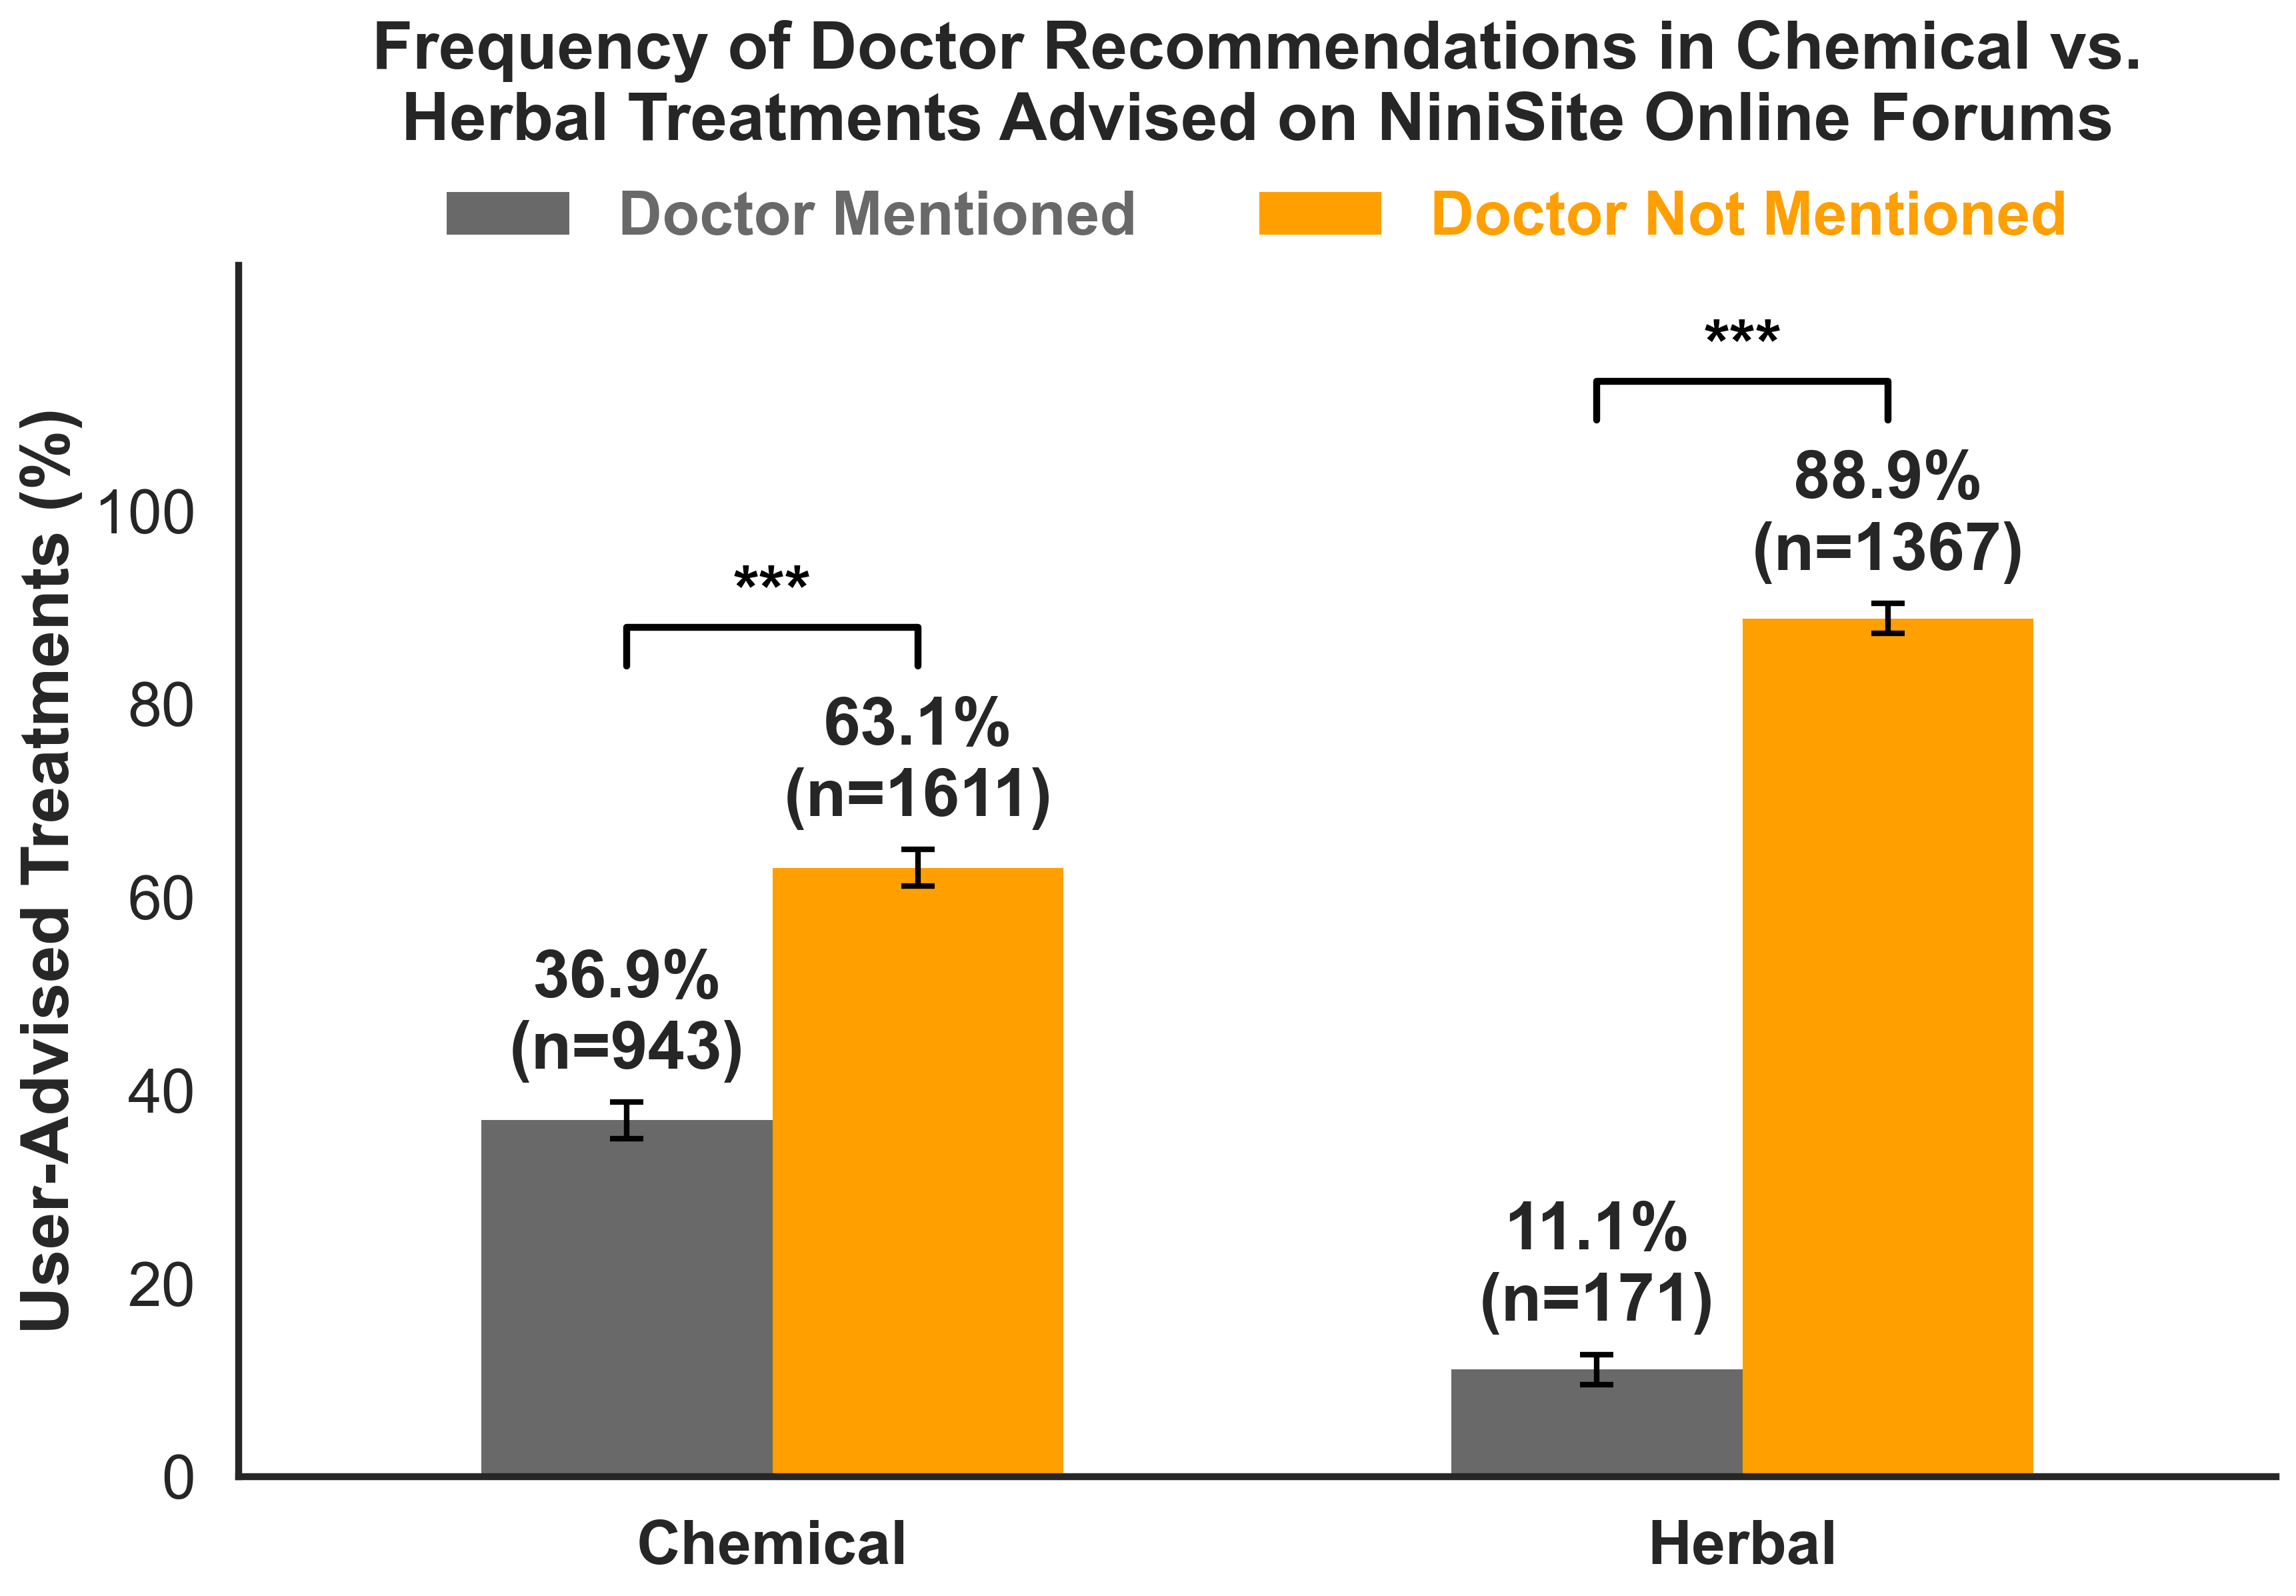

In [16]:
# Doctor recommended vs not recommended better plot
#====
# 1. Generate the raw counts crosstab first
raw_counts = pd.crosstab(
    sdf['is_doctor_mentioned'],
    sdf['treatment_category']
)

# 2. Drop the unnecessary category dynamically
if 'Home_Remedy(Not herbal/foods)' in raw_counts.columns:
    raw_counts.drop('Home_Remedy(Not herbal/foods)', axis=1, inplace=True)

# 3. Calculate percentages
totals = raw_counts.sum(axis=0)
raw_percentages = raw_counts.div(totals, axis=1) * 100

# Calculate 95% Confidence Intervals
# Formula: 1.96 * sqrt( (p * (100 - p)) / n )

variance = raw_percentages * (100 - raw_percentages)
se = np.sqrt(variance.div(totals, axis=1)) # Standard Error
ci_95 = 1.96 * se # 95% Margin of Error

# 4. Transpose ALL dataframes
df_plot_pct = raw_percentages.T 
df_plot_counts = raw_counts.T
df_plot_ci = ci_95.T # Transpose CI to match plot dimensions

# ==========================================
# 5. POSTER STYLE SETUP
# ==========================================
sns.set_style("white")
sns.set_context("poster") 

# Custom colors (Gray for True/Mentioned, Orange for False/Not Mentioned)
custom_colors = ["#696969", "#FF9F00"] 

# 6. Create the plot (Added yerr and capsize for the error bars)
fig, ax = plt.subplots(figsize=(12, 8.5))
df_plot_pct.plot(
    kind='bar', 
    color=custom_colors, 
    ax=ax, 
    # edgecolor='black', 
    edgecolor=None,
    # linewidth=2,
    linewidth=0,
    width=0.6,
    yerr=df_plot_ci,  # Add the CI error bars
    capsize=6,        # Add caps to the top/bottom of error bars
    error_kw={'elinewidth': 2, 'capthick': 2, 'ecolor': 'black'} # Style error bars
)

# ==========================================
# CUSTOMIZATION SECTION
# ==========================================
MY_TITLE = "Frequency of Doctor Recommendations in Chemical vs.\nHerbal Treatments Advised on NiniSite Online Forums"
MY_Y_LABEL = "User-Advised Treatments (%)"
MY_LEGEND_MENTIONED = "Doctor Mentioned"
MY_LEGEND_NOT_MENTIONED = "Doctor Not Mentioned"

# 7. Format the axes and titles
plt.title(MY_TITLE, fontweight='bold', pad=45) 
plt.xlabel("") 
plt.ylabel(MY_Y_LABEL, fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')

# 8. Legend Spacing Fixed
leg = plt.legend(labels=[MY_LEGEND_MENTIONED, MY_LEGEND_NOT_MENTIONED],
                 title="", loc='lower center', 
                 bbox_to_anchor=(0.5, 0.97), ncol=2, frameon=False)

for text, color in zip(leg.get_texts(), custom_colors):
    text.set_color(color)
    text.set_fontweight('bold')

# 9. Add the complex labels (Percentage + n)
# We use a separate counter (col_idx) to only track the bar columns, ignoring error bars
col_idx = 0
for container in ax.containers:
    # Only process actual bar containers
    if isinstance(container, container_module.BarContainer):
        custom_labels = []
        for j, bar in enumerate(container):
            pct_val = bar.get_height()                  
            count_val = df_plot_counts.iloc[j, col_idx]       
            label_str = f"{pct_val:.1f}%\n(n={count_val})"
            custom_labels.append(label_str)
        
        # Increased padding to float above the new error bars
        ax.bar_label(container, labels=custom_labels, padding=7, fontweight='bold')
        col_idx += 1
        
# 10. Add Significance Brackets (*** for p < 0.001)
offset = 0.15 

# Group 1: Chemical
x1, x2 = 0 - offset, 0 + offset
y_max1 = df_plot_pct.iloc[0].max() + df_plot_ci.iloc[0].max() # Account for CI height
y1, h1 = y_max1 + 19, 4          
ax.plot([x1, x1, x2, x2], [y1, y1+h1, y1+h1, y1], lw=2.5, c='black') 
ax.text((x1+x2)*.5, y1+h1, "***", ha='center', va='bottom', color='black', fontweight='bold')

# Group 2: Herbal
x3, x4 = 1 - offset, 1 + offset
y_max2 = df_plot_pct.iloc[1].max() + df_plot_ci.iloc[1].max() # Account for CI height
y2, h2 = y_max2 + 19, 4          
ax.plot([x3, x3, x4, x4], [y2, y2+h2, y2+h2, y2], lw=2.5, c='black')
ax.text((x3+x4)*.5, y2+h2, "***", ha='center', va='bottom', color='black', fontweight='bold')

# 11. Clean borders
ax.set_ylim(0, max(y1, y2) + 16)
sns.despine()

# 12. Remove 120 from the y-axis ticks
current_yticks = ax.get_yticks()
new_yticks = [tick for tick in current_yticks if tick <= 100]
ax.set_yticks(new_yticks)

# 13. Save
plt.tight_layout()
plt.savefig("Doctor_recommended.jpg", dpi=300, format='jpg')
plt.show()

### How many percentage of COMMENTS (not total drugs) advised chemical drugs mentioned Doctor?
### Because one comment may advised two chemical

In [17]:
for idx in df.index.unique():
    each_comment_df = df.loc[idx]
    try:
        is_at_least_one_chemical = any(each_comment_df['treatment_category']=='Chemical')
    except TypeError: # if just one item
        is_at_least_one_chemical = each_comment_df['treatment_category']=='Chemical'
        
    

# is_side_effect mentioned?

In [18]:
raw = pd.crosstab(
    sdf['is_side_effect'], 
    sdf['treatment_category'],
#     normalize='index'
)

# raw.plot(kind='bar')
raw

treatment_category,Chemical,Herbal,Home_Remedy(Not herbal/foods)
is_side_effect,,,
False,2063,1408,3167
True,491,130,244


In [19]:
p = pd.crosstab(
    sdf['is_side_effect'], 
    sdf['treatment_category'],
    normalize='columns'
) * 100


# p.plot(kind='bar')
p

treatment_category,Chemical,Herbal,Home_Remedy(Not herbal/foods)
is_side_effect,,,
False,80.775255,91.547464,92.846673
True,19.224745,8.452536,7.153327


In [20]:
raw

treatment_category,Chemical,Herbal,Home_Remedy(Not herbal/foods)
is_side_effect,,,
False,2063,1408,3167
True,491,130,244


In [21]:
print('Chemical')
print("Statistical analysis for one categorical (Chemical between two grout is_doctor_True and False)")

# Extract ONLY Chemical values
chem_m = raw.loc[True, 'Chemical']
chem_nm = raw.loc[False, 'Chemical']
total_chemical = chem_m + chem_nm

observed = [chem_m, chem_nm]

half_value_expected = total_chemical/2
expected = [half_value_expected, half_value_expected]  # 50-50 split: (943+1611)/2

chi2, p_value = chisquare(observed, expected)

print(f"χ²(1) = {chi2:.2f}, p = {p_value:.2e}")


# effect size Cohen's w (same as Phi for 2 groups)
n = total_chemical
w = np.sqrt(chi2 / n)
print(f"Cohen's w = {w:.3f}")

# Confidence interval 95%
# Proportions + CI
p_m = chem_m / total_chemical
p_nm = chem_nm / total_chemical
ci_m = proportion_confint(chem_m, total_chemical, method='wilson')
ci_nm = proportion_confint(chem_nm, total_chemical, method='wilson')



print("Confidence interval 95%")
print(f"\n Chemical side effects mentiond :      {p_m*100:.1f}% ({ci_m[0]*100:.1f}%–{ci_m[1]*100:.1f}%)")
print(f" Chemical  Not side effects mentiond : {p_nm*100:.1f}% ({ci_nm[0]*100:.1f}%–{ci_nm[1]*100:.1f}%)")

Chemical
Statistical analysis for one categorical (Chemical between two grout is_doctor_True and False)
χ²(1) = 967.57, p = 2.01e-212
Cohen's w = 0.616
Confidence interval 95%

 Chemical side effects mentiond :      19.2% (17.7%–20.8%)
 Chemical  Not side effects mentiond : 80.8% (79.2%–82.3%)


In [22]:
print('Herbal')
print("Statistical analysis for one categorical (Herbal between two grout is_doctor_True and False)")

# Extract ONLY Herbal values
herb_m = raw.loc[True, 'Herbal']
herb_nm = raw.loc[False, 'Herbal']
total_Herbal = herb_m + herb_nm

observed = [herb_m, herb_nm]

half_value_expected = total_Herbal/2
expected = [half_value_expected, half_value_expected]  # 50-50 split: (943+1611)/2

chi2, p_value = chisquare(observed, expected)

print(f"χ²(1) = {chi2:.2f}, p = {p_value:.2e}")


# effect size Cohen's w (same as Phi for 2 groups)
n = total_Herbal
w = np.sqrt(chi2 / n)
print(f"Cohen's w = {w:.3f}")

# Confidence interval 95%
# Proportions + CI
p_m = herb_m / total_Herbal
p_nm = herb_nm / total_Herbal
ci_m = proportion_confint(herb_m, total_Herbal, method='wilson')
ci_nm = proportion_confint(herb_nm, total_Herbal, method='wilson')



print("Confidence interval 95%")
print(f"\n Herbal side effects mentiond :      {p_m*100:.1f}% ({ci_m[0]*100:.1f}%–{ci_m[1]*100:.1f}%)")
print(f" Herbal  Not side effects mentiond : {p_nm*100:.1f}% ({ci_nm[0]*100:.1f}%–{ci_nm[1]*100:.1f}%)")

Herbal
Statistical analysis for one categorical (Herbal between two grout is_doctor_True and False)
χ²(1) = 1061.95, p = 6.14e-233
Cohen's w = 0.831
Confidence interval 95%

 Herbal side effects mentiond :      8.5% (7.2%–9.9%)
 Herbal  Not side effects mentiond : 91.5% (90.1%–92.8%)


# Top most frequent drugs

In [23]:
chem_df = find('treatment_category', 'Chemical')
chem_df.treatment_name.value_counts().iloc[:100]

treatment_name
Acetaminophen                  142
Diphenhydramine                 94
Vitamin C                       78
Azithromycin                    73
Antibiotic                      68
Injection                       61
Cetirizine                      56
Amoxicillin                     55
Paracetamol                     45
Antibiotics                     41
Cold medicine                   38
Antihistamine                   37
Medication                      31
Cefixime                        29
Vitamin D                       27
Diphenhydramine syrup           26
Syrup                           25
Penicillin                      24
Serum                           24
Pills                           22
Amoxiclav                       21
Cold Medicine                   20
Zinc                            20
Nasal drops                     17
Coldax                          17
                              ... 
Effervescent Tablet              5
Sodium Chloride Nasal Drops      5
Cold 

In [24]:
# to know Discouraged ones
for value in chem_df.treatment_status.value_counts().index: #e.g. Discouraged, Adviced, ....
    print(value)
    r = chem_df[chem_df['treatment_status']==value]['treatment_name'].value_counts().iloc[0:8]
    print(r)
    print()

Definitive Advice
treatment_name
Acetaminophen      65
Vitamin C          48
Diphenhydramine    33
Azithromycin       29
Cold medicine      19
Cetirizine         19
Antibiotic         19
Antihistamine      17
Name: count, dtype: int64

Administered/Experienced
treatment_name
Acetaminophen      34
Diphenhydramine    29
Injection          28
Amoxicillin        27
Azithromycin       26
Paracetamol        19
Cetirizine         17
Antibiotic         17
Name: count, dtype: int64

Asking
treatment_name
Injection          14
Acetaminophen      13
Diphenhydramine    11
Antibiotic         11
Cetirizine          9
Azithromycin        9
Amoxicillin         8
Antihistamine       8
Name: count, dtype: int64

With_Caution Advice
treatment_name
Vitamin C        17
Cetirizine        8
Acetaminophen     8
Antibiotic        6
Medication        5
Paracetamol       5
Syrup             5
Azithromycin      4
Name: count, dtype: int64

With_Caution_Advice
treatment_name
Acetaminophen      12
Diphenhydramine  

# Top most frequent Herbals

In [25]:
herb_df = find('treatment_category', 'Herbal')
herb_df.treatment_name.value_counts().iloc[:10]

treatment_name
Thyme         84
Turnip        72
Ginger        60
Thyme tea     47
Honey         41
Thyme Tea     35
Herbal Tea    34
Garlic        34
Herbal tea    32
Cinnamon      32
Name: count, dtype: int64

In [26]:
# to know Discouraged ones
for value in herb_df.treatment_status.value_counts().index: #e.g. Discouraged, Adviced, ....
    print(value)
    r = herb_df[herb_df['treatment_status']==value]['treatment_name'].value_counts().iloc[0:8]
    print(r)
    print()

Definitive Advice
treatment_name
Thyme         34
Turnip        32
Thyme tea     30
Ginger        28
Honey         20
Garlic        19
Thyme Tea     18
Herbal tea    16
Name: count, dtype: int64

With_Caution Advice
treatment_name
Thyme         21
Turnip        20
Ginger        15
Cinnamon      12
Jujube        11
Herbal Tea    10
Garlic        10
Thyme Tea     10
Name: count, dtype: int64

Administered/Experienced
treatment_name
Honey        11
Thyme         9
Turnip        7
Turmeric      7
Ginger        7
Lemon         6
Thyme tea     6
Thyme Tea     5
Name: count, dtype: int64

With_Caution_Advice
treatment_name
Thyme         8
Turnip        7
Pennyroyal    6
Ginger        5
Thyme tea     4
Lemon         3
Honey         3
Oregano       3
Name: count, dtype: int64

Asking
treatment_name
Turnip        6
Thyme         4
Pennyroyal    3
Herbal Tea    3
Thyme Tea     2
Hibiscus      2
Barley        2
Lavender      2
Name: count, dtype: int64

Definitive Discouraged
treatment_name
Thyme 

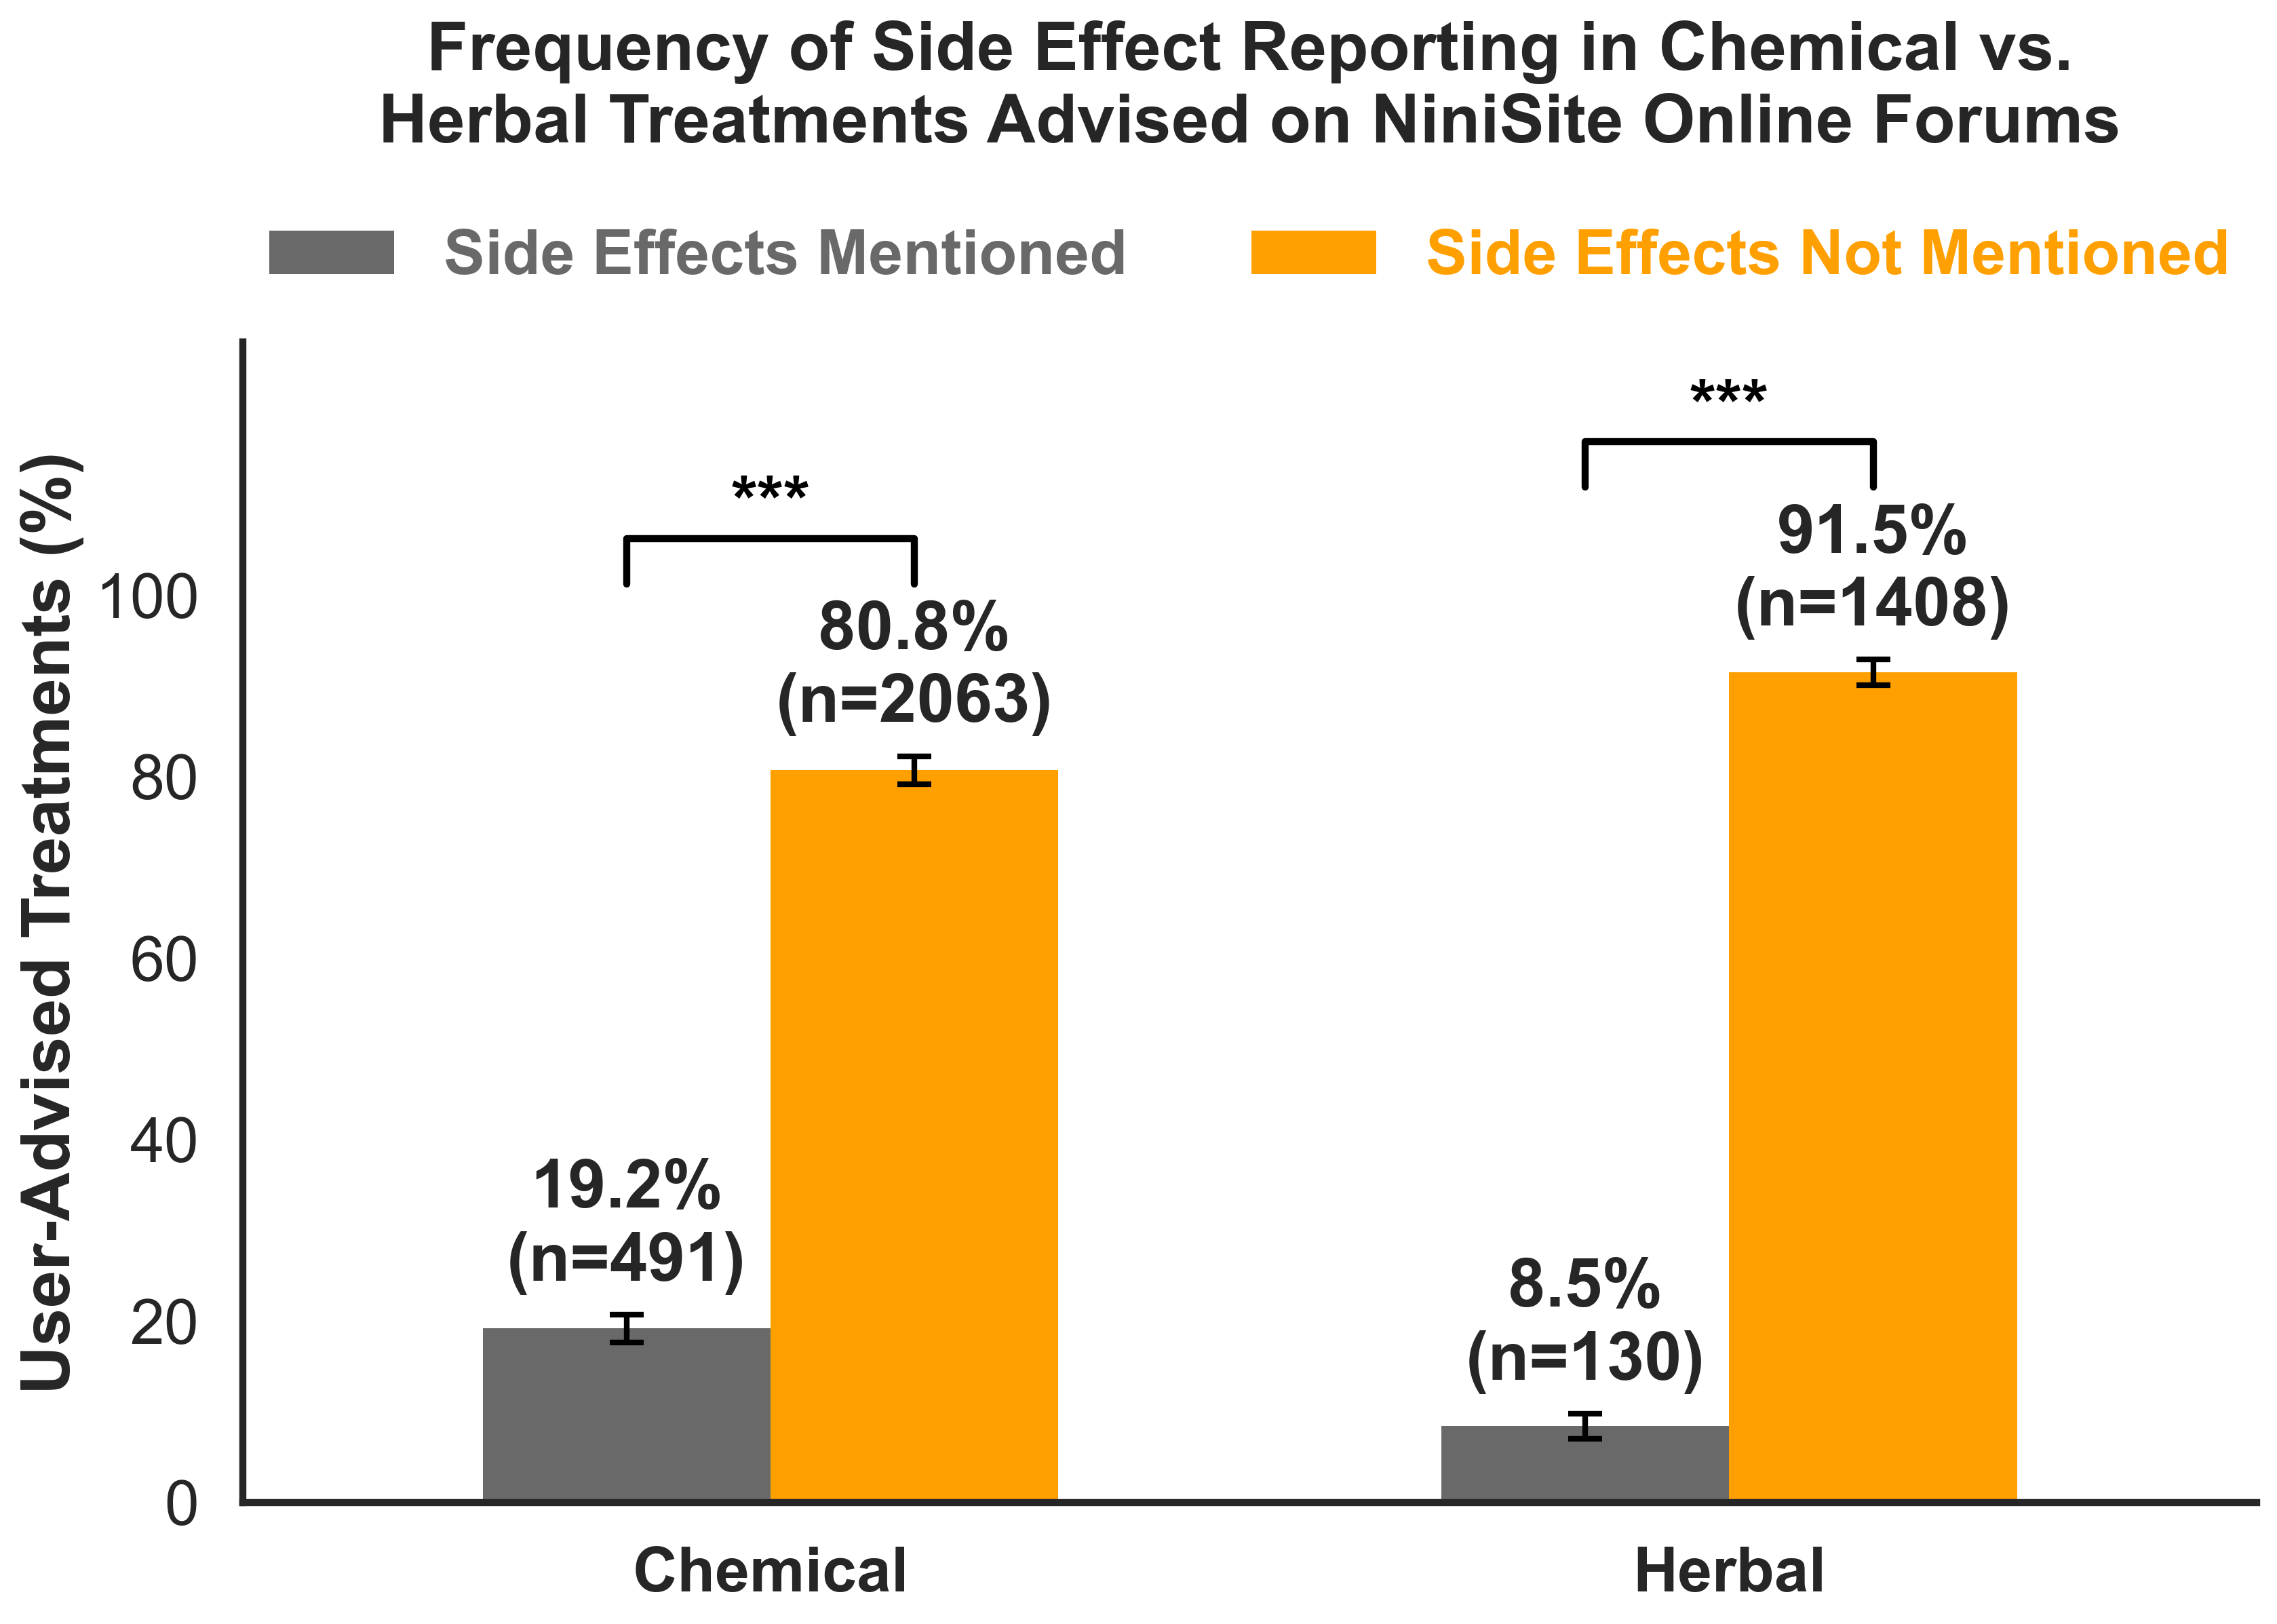

In [27]:
# 1. Generate the raw counts crosstab first
raw_counts = pd.crosstab(
    sdf['is_side_effect'], 
    sdf['treatment_category']
)

# 2. Drop the unnecessary category dynamically
if 'Home_Remedy(Not herbal/foods)' in raw_counts.columns:
    raw_counts.drop('Home_Remedy(Not herbal/foods)', axis=1, inplace=True)

# ---------------------------------------------------------
# NEW FIX: Reorder the index so True comes before False!
# ---------------------------------------------------------
raw_counts = raw_counts.reindex([True, False])

# 3. Calculate percentages
totals = raw_counts.sum(axis=0)
raw_percentages = raw_counts.div(totals, axis=1) * 100

# Calculate 95% Confidence Intervals
# Formula: 1.96 * sqrt( (p * (100 - p)) / n )

variance = raw_percentages * (100 - raw_percentages)
se = np.sqrt(variance.div(totals, axis=1)) # Standard Error
ci_95 = 1.96 * se # 95% Margin of Error

# 4. Transpose ALL dataframes
df_plot_pct = raw_percentages.T 
df_plot_counts = raw_counts.T
df_plot_ci = ci_95.T # Transpose CI to match plot dimensions

# ==========================================
# 5. POSTER STYLE SETUP
# ==========================================
sns.set_style("white")
sns.set_context("poster") 

# Custom colors (Gray for True/Mentioned, Orange for False/Not Mentioned)
custom_colors = ["#696969", "#FF9F00"] 

# 6. Create the plot (Added yerr and capsize for the error bars)
fig, ax = plt.subplots(figsize=(12, 8.5))
df_plot_pct.plot(
    kind='bar', 
    color=custom_colors, 
    ax=ax, 
    # edgecolor='black', 
    edgecolor=None,
    # linewidth=2,
    linewidth=0,
    width=0.6,
    yerr=df_plot_ci,  # Add the CI error bars
    capsize=6,        # Add caps to the top/bottom of error bars
    error_kw={'elinewidth': 2, 'capthick': 2, 'ecolor': 'black'} # Style error bars
)

# ==========================================
# CUSTOMIZATION SECTION
# ==========================================
MY_TITLE = "Frequency of Side Effect Reporting in Chemical vs.\nHerbal Treatments Advised on NiniSite Online Forums\n"
MY_Y_LABEL = "User-Advised Treatments (%)"
MY_LEGEND_MENTIONED = "Side Effects Mentioned"
MY_LEGEND_NOT_MENTIONED = "Side Effects Not Mentioned"

# 7. Format the axes and titles
plt.title(MY_TITLE, fontweight='bold', pad=45) 
plt.xlabel("") 
plt.ylabel(MY_Y_LABEL, fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')

# 8. Legend Spacing Fixed
leg = plt.legend(labels=[MY_LEGEND_MENTIONED, MY_LEGEND_NOT_MENTIONED],
                 title="", loc='lower center', 
                 bbox_to_anchor=(0.5, 1), ncol=2, frameon=False)

for text, color in zip(leg.get_texts(), custom_colors):
    text.set_color(color)
    text.set_fontweight('bold')

# 9. Add the complex labels (Percentage + n)
# We use a separate counter (col_idx) to only track the bar columns, ignoring error bars
col_idx = 0
for container in ax.containers:
    # Only process actual bar containers
    if isinstance(container, container_module.BarContainer):
        custom_labels = []
        for j, bar in enumerate(container):
            pct_val = bar.get_height()                  
            count_val = df_plot_counts.iloc[j, col_idx]       
            label_str = f"{pct_val:.1f}%\n(n={count_val})"
            custom_labels.append(label_str)
        
        # Increased padding to float above the new error bars
        ax.bar_label(container, labels=custom_labels, padding=7, fontweight='bold')
        col_idx += 1
        
# 10. Add Significance Brackets (*** for p < 0.001)
offset = 0.15 

# Group 1: Chemical
x1, x2 = 0 - offset, 0 + offset
y_max1 = df_plot_pct.iloc[0].max() + df_plot_ci.iloc[0].max() # Account for CI height
y1, h1 = y_max1 + 19, 5          
ax.plot([x1, x1, x2, x2], [y1, y1+h1, y1+h1, y1], lw=2.5, c='black') 
ax.text((x1+x2)*.5, y1+h1, "***", ha='center', va='bottom', color='black', fontweight='bold')

# Group 2: Herbal
x3, x4 = 1 - offset, 1 + offset
y_max2 = df_plot_pct.iloc[1].max() + df_plot_ci.iloc[1].max() # Account for CI height
y2, h2 = y_max2 + 19, 5          
ax.plot([x3, x3, x4, x4], [y2, y2+h2, y2+h2, y2], lw=2.5, c='black')
ax.text((x3+x4)*.5, y2+h2, "***", ha='center', va='bottom', color='black', fontweight='bold')

# 11. Clean borders
ax.set_ylim(0, max(y1, y2) + 16)
sns.despine()

# 12. Remove 120 from the y-axis ticks
current_yticks = ax.get_yticks()
new_yticks = [tick for tick in current_yticks if tick <= 100]
ax.set_yticks(new_yticks)

# 13. Save
plt.tight_layout()
plt.savefig("side_effect_mentioned.jpg", dpi=300, format='jpg')
plt.show()